In [1]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
def overlay_detection(model, image_path, output_path=None, only_class=None):
    results = model.predict(image_path)
    img = cv2.imread(image_path)

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]

            # filter class
            if only_class is not None and class_name not in only_class:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            label = f"{class_name} {conf:.2f}"

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    if output_path:
        cv2.imwrite(output_path, img)

    return img[:, :, ::-1]

def overlay_segmentation(model, image_path, output_path=None):
    results = model.predict(image_path)
    img = cv2.imread(image_path)
    for r in results:
        # Jika model memiliki masks (segmentation)
        if r.masks is not None:
            masks = r.masks.data.cpu().numpy()
            
            # Iterasi setiap mask untuk setiap deteksi
            for idx, mask in enumerate(masks):
                # Normalisasi mask ke ukuran image
                mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]))
                
                # Buat warna acak untuk setiap mask
                color = (0, 255, 255)  # BGR format (Cyan)
                
                # Buat overlay dengan transparansi
                overlay = img.copy()
                overlay[mask_resized > 0.5] = color
                
                # Blend original image dengan overlay
                img = cv2.addWeighted(overlay, 0.3, img, 0.7, 0)
            

        else:
            print("tidak terdeteksi")

    if output_path:
        cv2.imwrite(output_path, img)
    
    return img[:,:,::-1]

In [4]:
license_segmentation_model = YOLO("../models/license_plate_segment.pt")
car_detection_model = YOLO("../models/car_detector.pt")


image 1/1 d:\Madebyhumans\client_ppq\notebooks\..\images\mobil_test.jpg: 480x640 1 mobil, 222.7ms
Speed: 7.2ms preprocess, 222.7ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)


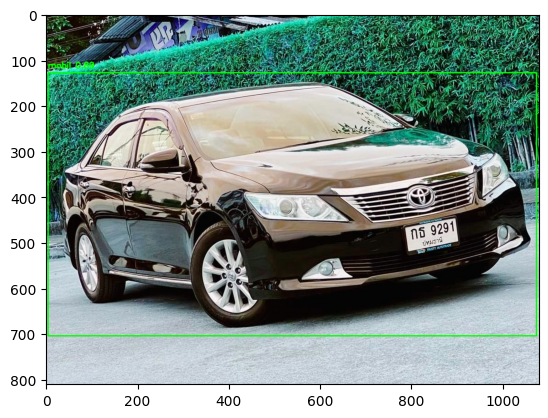

In [5]:
plt.imshow(overlay_detection(car_detection_model, "../images/mobil_test.jpg", only_class=["mobil", "motor"])[:,:,::-1])

image 1/1 d:\Madebyhumans\client_ppq\notebooks\..\images\00164.jpg: 384x640 1 plate, 84.1ms
Speed: 10.9ms preprocess, 84.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


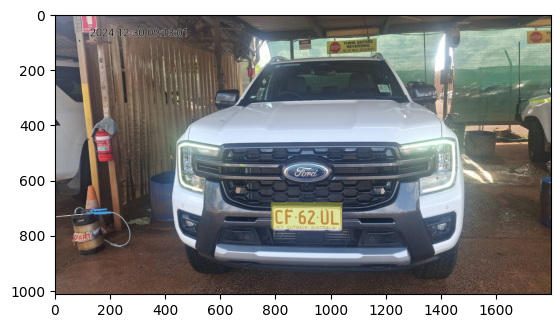

In [6]:
plt.imshow(overlay_segmentation(license_segmentation_model, "../images/00164.jpg"))